In [1]:
savecache=1
loadcache=0

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from dataclasses import asdict
from functools import partial
from ciceroscm import input_handler
import pandas as pd
from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [3]:
import matplotlib.cm as cm

In [4]:
from meteor import prpatt

In [5]:
from scipy.linalg import pinv

In [6]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


In [7]:
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM

Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [8]:
expts=["piControl", "abrupt-4xCO2", "historical","ssp585", "ssp245","ssp126"]
expts.index('historical')

2

In [13]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "1pctCO2", "historical","ssp585", "ssp245","ssp126"], flds = flds, dbe=['CMIP','CMIP','CMIP','CMIP', 'ScenarioMIP','ScenarioMIP','ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
# 'ACCESS-ESM1-5',
models=['NorESM2-MM','CanESM5']


Model ACCESS-CM2 has full data
Model ACCESS-ESM1-5 has full data
Model AWI-CM-1-1-MR has full data
Model AWI-ESM-1-1-LR has insufficient data
Model BCC-CSM2-MR has full data
Model BCC-ESM1 has insufficient data
Model CAMS-CSM1-0 has full data
Model CAS-ESM2-0 has full data
Model CESM2 has full data
Model CESM2-FV2 has insufficient data
Model CESM2-WACCM has full data
Model CESM2-WACCM-FV2 has insufficient data
Model CIESM has insufficient data
Model CMCC-CM2-SR5 has full data
Model CMCC-ESM2 has full data
Model CNRM-CM6-1 has full data
Model CNRM-CM6-1-HR has full data
Model CNRM-ESM2-1 has full data
Model CanESM5 has full data
Model CanESM5-CanOE has insufficient data
Model E3SM-1-0 has insufficient data
Model E3SM-1-1 has insufficient data
Model E3SM-1-1-ECA has insufficient data
Model EC-Earth3 has full data
Model EC-Earth3-AerChem has insufficient data
Model EC-Earth3-CC has insufficient data
Model EC-Earth3-LR has insufficient data
Model EC-Earth3-Veg has full data
Model EC-Earth3

Getting some data that can be used by the forcer engine and ciceroscm

In [14]:
data_getter.models

['ACCESS-CM2',
 'ACCESS-ESM1-5',
 'AWI-CM-1-1-MR',
 'BCC-CSM2-MR',
 'CAMS-CSM1-0',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-WACCM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-CM6-1-HR',
 'CNRM-ESM2-1',
 'CanESM5',
 'EC-Earth3',
 'EC-Earth3-Veg',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'GFDL-ESM4',
 'GISS-E2-1-G',
 'GISS-E2-1-H',
 'HadGEM3-GC31-LL',
 'IITM-ESM',
 'INM-CM4-8',
 'INM-CM5-0',
 'IPSL-CM6A-LR',
 'KACE-1-0-G',
 'KIOST-ESM',
 'MCM-UA-1-0',
 'MIROC-ES2L',
 'MIROC6',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NESM3',
 'NorESM2-MM',
 'TaiESM1',
 'UKESM1-0-LL']

In [15]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
#read in SSP245 concentrations and emissions

scenarios = ["ssp126","ssp245","ssp585"]

conc_data=[]
em_data=[]
for i,s in enumerate(scenarios):
    conc_data.append(input_handler.read_inputfile(
    os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")
    ))

    em_data.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

Getting training data to use for predictions:

In [16]:
if not loadcache:
    test_data={}
    for m in models:
        print(m)
        test_data[m] = {

            "base": data_getter.make_meteor_training_data("base", m), #control simulation
            "co2x4": data_getter.make_meteor_training_data("co2x4", m), #co2 only response
            "1pc": data_getter.make_meteor_training_data("1pc", m)} #co2 only response
            
        for s in scenarios:
                test_data[m][s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], m
                    )


NorESM2-MM
NorESM2-MM
piControl
tas
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/tas/gn/v20191108/
NorESM2-MM
piControl
pr
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/pr/gn/v20191108/
NorESM2-MM
abrupt-4xCO2
tas
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/abrupt-4xCO2/r1i1p1f1/Amon/tas/gn/v20191108/
NorESM2-MM
abrupt-4xCO2
pr
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/abrupt-4xCO2/r1i1p1f1/Amon/pr/gn/v20191108/
NorESM2-MM
1pctCO2
tas
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/1pctCO2/r1i1p1f1/Amon/tas/gn/v20191108/
NorESM2-MM
1pctCO2
pr
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/1pctCO2/r1i1p1f1/Amon/pr/gn/v20191108/
NorESM2-MM
historical
tas
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/historical/r1i1p1f1/Amon/tas/gn/v20191108/
NorESM2-MM
ssp126
tas
gs://cmip6/CMIP6/ScenarioMIP/NCC/NorESM2-MM/ssp126/r1i1p1f1/Amon/tas/gn/v20191108/
NorESM2-MM
historical
pr
gs://cmip6/CMIP6/CMIP/NCC/NorESM2-MM/historical/r1i1p1f1/Amon/pr/gn/v20191108/
NorESM2-MM
ssp126
pr
gs://cmip6/CMIP6/ScenarioMIP/NC

In [ ]:
if savecache:
    cachedir = os.path.join(os.getcwd(), "cache")
    if not os.path.exists(cachedir):
        os.makedirs(cachedir)
    for m in models:
        for k in test_data[m]:
            test_data[m][k].to_netcdf(
                os.path.join(cachedir, f"{m}_{k}_test_data.nc")
            )

In [ ]:
if loadcache:
    cachedir = os.path.join(os.getcwd(), "cache")

    test_data={}
    for m in models:
        test_data[m] = {
            "base": xr.open_dataset(
                os.path.join(cachedir, f"{m}_base_test_data.nc")
            ),
            "co2x4": xr.open_dataset(
                os.path.join(cachedir, f"{m}_co2x4_test_data.nc")
            ),
            "1pc": xr.open_dataset(
                os.path.join(cachedir, f"{m}_1pc_test_data.nc")
            ),
        }
        for s in scenarios:
            test_data[m][s] = xr.open_dataset(
                os.path.join(cachedir, f"{m}_{s}_test_data.nc")
            )
        test_data[m]["sulxanom"]=test_data[m]["ssp245"]
        

Making patterns one with just co2x4, and one including the sulfate from residual in the experiment. The fisrt will include just base (piControl) and co2x4 (abrupt4xCO2), the second will also have a sulxanom which we take from the historical and ssp245 composite experiment

First encode the pure CO2 response

In [ ]:
%%capture
ghg_pattern = {}
for m in models:
    ghg_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-ghg",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )

Now encode a set of patterns, including the historical/future composite

In [ ]:
%%capture
anomsulf_pattern = {}
for m in models:
    anomsulf_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-anomsulf",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

In [ ]:
canesm_anomsulf_pattern.exp_forc_dict

{'base': 0.0, 'co2x4': 8.534700743147258, 'sulxanom': 1.0}

Then taking the data from the ssp-data for ciceroscm and making predictions

In [ ]:
%%capture
patterns_ghg={}
patterns_anomsulf={}
for m in models:
    patterns_ghg[m]={}
    patterns_anomsulf[m]={}

    for i,s in enumerate(scenarios):
        patterns_ghg[m][s]=(ghg_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )
        patterns_anomsulf[m][s]=(anomsulf_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )

Plotting global means for the CMIP6 data, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

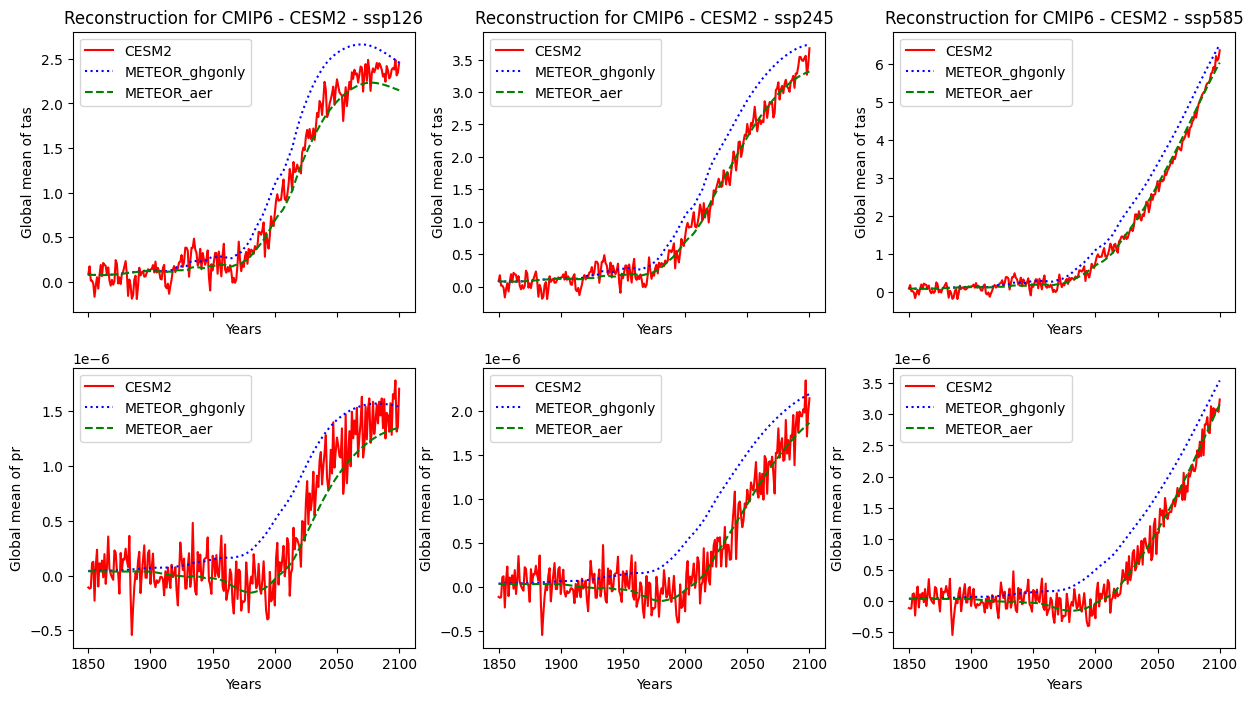

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=len(scenarios), sharex=True,figsize=(15,8))
m="CESM2"
for i,s in enumerate(scenarios):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(test_data[m]["base"][fld]).values)
        total_years = len(test_data[m]["sulxanom"][fld]["year"].values)
        years_to_plot = range(1850,1850+total_years)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(test_data[m][s][fld]).values[0,:]-zero_val, color="red", label=m)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_ghg[m][s][fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf[m][s][fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Reconstruction for CMIP6 - "+m+" - "+s)
        axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[j,i].legend()

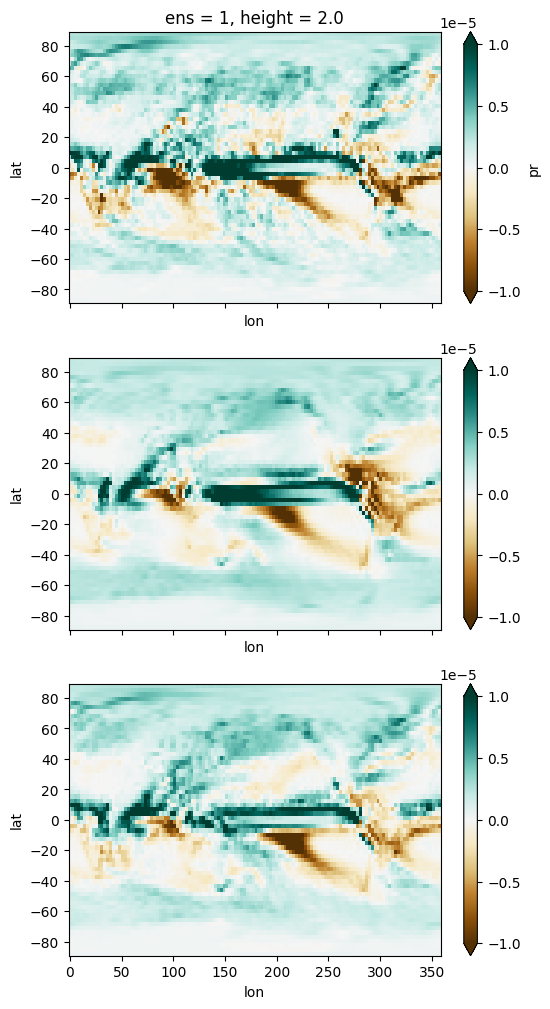

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True,figsize=(6,12))
plt.set_cmap('bwr')
tmpw=(training_data["sulxanom"]['pr'][0,180:200,:,:].mean(dim='year')-(training_data["sulxanom"]['pr'][0,140:160,:,:]).mean(dim='year'))
tmpw.plot(ax=axs[0],cmap=cm.BrBG,vmin=-10e-6,vmax=10e-6)

tmpw=(patterns_ghg['pr'][280:300,:,:].mean(dim='time')-(patterns_ghg['pr'][240:260,:,:]).mean(dim='time'))
tmpw.plot(ax=axs[1],cmap=cm.BrBG,vmin=-10e-6,vmax=10e-6)

tmpw=(patterns_anomsulf['pr'][280:300,:,:].mean(dim='time')-(patterns_anomsulf['pr'][240:260,:,:]).mean(dim='time'))
tmpw.plot(ax=axs[2],cmap=cm.BrBG,vmin=-10e-6,vmax=10e-6)

In [ ]:
from global_land_mask import globe


In [ ]:
lat=tmpw.lat
lon=tmpw.lon
lon = np.where(lon > 180, lon-360, lon)

lon_grid, lat_grid = np.meshgrid(lon,lat)
is_in_ocean = globe.is_ocean(lat_grid, lon_grid)

In [ ]:
is_in_ocean

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

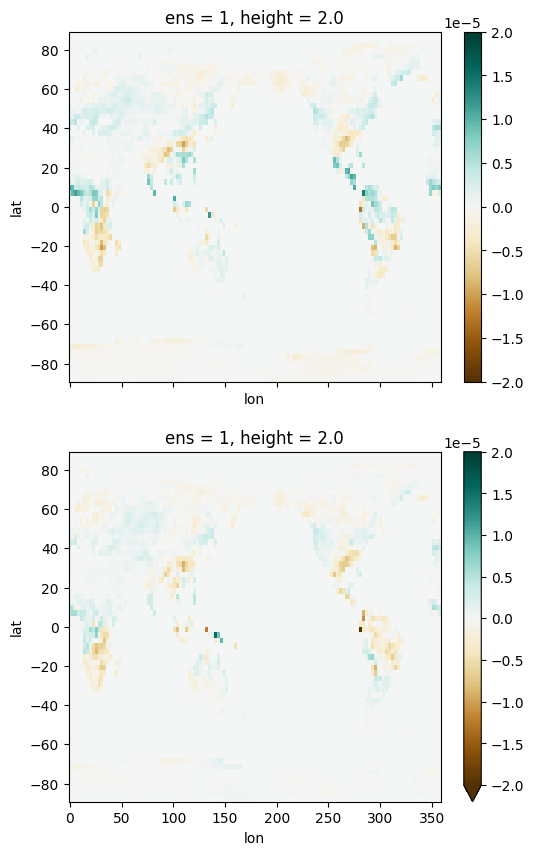

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True,figsize=(6,10))
plt.set_cmap('bwr')
tmpw=(training_data["sulxanom"]['pr'][0,190:210,:,:].mean(dim='year')-(training_data["sulxanom"]['pr'][0,140:160,:,:]).mean(dim='year'))

tmpp=(patterns_ghg['pr'][290:310,:,:].mean(dim='time')-(patterns_ghg['pr'][240:260,:,:]).mean(dim='time'))
((tmpw-tmpp)*~is_in_ocean).plot(ax=axs[0],cmap=cm.BrBG,vmin=-20e-6,vmax=20e-6)

tmpp2=(patterns_anomsulf['pr'][290:310,:,:].mean(dim='time')-(patterns_anomsulf['pr'][240:260,:,:]).mean(dim='time'))
((tmpw-tmpp2)*~is_in_ocean).plot(ax=axs[1],cmap=cm.BrBG,vmin=-20e-6,vmax=20e-6)

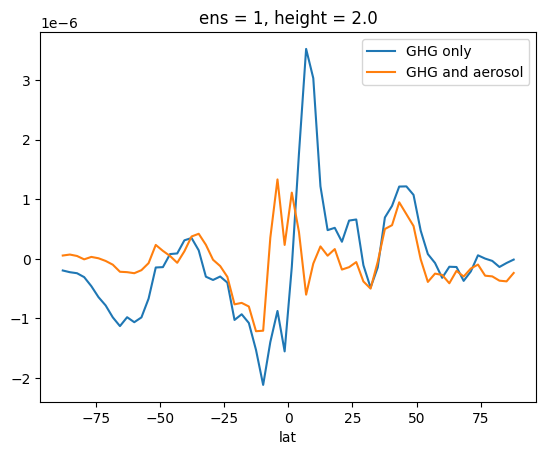

In [ ]:
(tmpw-tmpp).mean('lon').plot(label='GHG only')
(tmpw-tmpp2).mean('lon').plot(label='GHG and aerosol')
plt.legend()

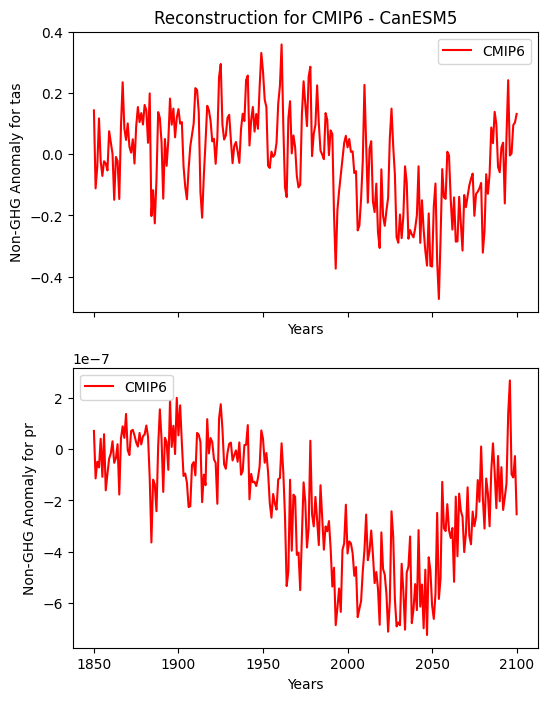

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=1, sharex=True,figsize=(6,8))

for j, fld in enumerate(flds):
    zero_val = np.mean(prpatt.global_mean(training_data["base"][fld]).values)
    total_years = len(training_data["sulxanom"][fld]["year"].values)
    years_to_plot = range(1850,1850+total_years)
    axs[j].plot(years_to_plot, prpatt.global_mean(training_data["sulxanom"][fld]).values[0,:]-zero_val- prpatt.global_mean(patterns_ghg[fld]).values[100:], color="red", label="CMIP6")
   # axs[j].plot(years_to_plot, prpatt.global_mean(patterns_ghg[fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
    #axs[j].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf[fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
    axs[j].set_xlabel("Years")
    if j == 0:
        axs[j].set_title(f"Reconstruction for CMIP6 - CanESM5")
    axs[j].set_ylabel(f"Non-GHG Anomaly for {fld}")
    axs[j].legend()

In [ ]:
patterns_ghg[fld]

<xarray.DataArray (time: 351, lat: 64, lon: 128)> Size: 23MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.37984739e-11, 2.34016028e-11, 2.28088594e-11, ...,
         2.53516528e-11, 2.49509013e-11, 2.45368822e-11],
        [1.91681308e-11, 1.83135732e-11, 1.75165752e-11, ...,
         2.09852130e-11, 2.06123101e-11, 2.00598553e-11],
        [1.56561864e-11, 1.54016530e-11, 1.51559523e-11, ...,
         1.87941777e-11, 1.73798199e-11, 1.64339525e-11],
...
        [5.24477065e-06, 5.28361140e-06, 5.14267475e-06, ...,
         4.82888910e-06, 4.92994648e-06, 5.10636376e-06],
        [5.09425538e-06, 5.11066563e-06, 5.05389900e-06, ...,
         4.95367756e-06, 4.98294603e-06, 5.03651919e-06],
        [4.94590982e-06, 4.93283987e-06, 4.92226193e-06, ...,
         5.03600651e-06, 5.02448577e-06, 4.97155501e-06]],

       [[1.29542320e-06, 1.29348261e-06, 1.28666134e-06, ...,
         1.29590114e-06, 1.29282007e-06, 1.29256261e-06],
        [9.71475269e-07, 9.51337692e-07, 9.26541919e-07, ...,
         1.04668308e-06, 1.02798616e-06, 9.97337996e-07],
        [1.02131495e-06, 9.84873696e-07, 9.41865207e-07, ...,
         1.10443712e-06, 1.06753343e-06, 1.03890790e-06],
        ...,
        [5.25359878e-06, 5.29178352e-06, 5.14866139e-06, ...,
         4.83387207e-06, 4.93697559e-06, 5.11413640e-06],
        [5.09668697e-06, 5.11389379e-06, 5.05672826e-06, ...,
         4.95364497e-06, 4.98343885e-06, 5.03723743e-06],
        [4.94796106e-06, 4.93548966e-06, 4.92536609e-06, ...,
         5.03722778e-06, 5.02633292e-06, 4.97319718e-06]]])
Coordinates:
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * time     (time) datetime64[ns] 3kB 1750-01-01 1751-01-01 ... 2100-01-01

In [ ]:
canesm_anomsulf_pattern.